In [1]:
from glob import glob 
import matplotlib.pyplot as plt 
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np 
import pandas as pd
from importlib import reload
import matplotlib.gridspec as gridspec
from matplotlib.cm import get_cmap,  ScalarMappable
import meanfield.hebbian_meanfield as mf
from collections import defaultdict
from glob import glob
import seaborn as sns
from scipy.optimize import fsolve
from tqdm import tqdm
import os
import colormaps as cmaps
from matplotlib.colors import ListedColormap

import matplotlib.cm as cm
import string
import matplotlib.colors as mcolors
import colormaps as cmaps
outdir = '/mnt/home/awakhloo/ceph/persistent-oscillations/results'
figdir = '/mnt/home/awakhloo/ceph/persistent-oscillations/figs'

ModuleNotFoundError: No module named 'diffrax'

In [ ]:
def load_outlier_dat(path, eps = 0.075): 
    files = glob(path + '/*.npy')
    dfs = [] 
    for f in files: 
        arr = np.load(f, allow_pickle=True).item() 
        if 'freqs' not in arr.keys():
            continue 
        I, g, k, p, f, life, freqs  = arr['I'], arr['g'], arr['k'], arr['p'], arr['f'], arr['life'], arr['freqs'] 
        eig = arr['eigs']
        if type(eig)==list: eig = np.stack(eig) 
        # get the outlier for each batch and timepoint
        n_times, n_batch, N = eig.shape
        # assert n_times ==1 
        if n_times !=1: 
            print('check')
            continue 
        eig = eig.squeeze() 
        ind = np.abs(eig).argmax(axis=-1)
        eig = eig[np.arange(n_batch), ind] # outliers 
        # threshold outliers
        eig[np.abs(eig) <= g + eps] = 0.
        # data formatting
        dct = {'I' : np.ones(n_batch) * I,
               'f' :  np.ones(n_batch) * f,
               'k' :  np.ones(n_batch) * k,
               'p' :  np.ones(n_batch) * p, 
               'g' : np.ones(n_batch) * g,
               'life' : life, 
               'freqs' : freqs,
               'eig_re' : eig.real,
              'eig_im' : eig.imag}
        df = pd.DataFrame(dct, index=np.arange(n_batch))
        X = arr['Xh']
        dfs.append(df)
    return pd.concat(dfs,ignore_index=True), X

# def a4(mu, k, g, I, omega, phi=np.tanh): 
#     ''' mu = <L^2>'''
#     lam = k/4 * phi(mu) 
#     gam = np.sqrt(phi(mu) / mu )    
    
#     # gam = phi(np.sqrt(mu))/np.sqrt(mu) 
#     # lam = k/4 * gam**2 * mu 

#     # gam = 4/np.pi/np.sqrt(mu) 
#     # lam = k/4 * gam**2 * mu 

#     z = (1 + 1j * omega - lam*gam)
#     return mu * (np.abs(z)**2 - g**2 * gam**2) - I**2

# def get_the(I, k, g, omega, phi=np.tanh): 
#     eqn = lambda mu: a4(mu, k, g, I, omega)
#     mu0= 10 #I #1
#     mu = fsolve(eqn, mu0)
#     lam = k/4 * phi(mu)
#     gamma = np.sqrt(phi(mu) / mu )

    
#     # gamma = phi(np.sqrt(mu))/np.sqrt(mu) 
#     # lam = k/4 * gamma**2 * mu 
#     # gamma = 4/np.pi/np.sqrt(mu)
#     # lam = k/4 * gamma**2 * mu 

    
#     z = (1+1j*omega - lam*gamma)
#     alpha = I**2 * k /(4)
#     eta = z/gamma 
#     if np.abs(eta) < g: print("I = ", I , "OM = ", omega, ' o fuqqq') 
#     if np.abs(eqn(mu)) > 1e-3 :  print("I = ", I , "OM = ", omega, ' o fuqqq')  
#     eigs_t = alpha/(np.abs(eta)**2 - g**2) + g**2/np.conj(eta) 

#     # if 1 - gamma * lam - gamma * g < 0 : 
#     #     print('oo') 
#     #     return 0,0 #np.nan, np.nan 
    
#     return eigs_t * (np.abs(eigs_t) > g), eta

def a4(gam, k, g, I, omega, phi=np.tanh): 
    gain = phi(I)
    lam = k/4  *  gain
    return gam**2 * I**2 - gain*(((1-gam*lam)**2 + omega**2) - g**2 * gam**2)

def get_the(I, k, g, omega, phi=np.tanh, eps=0.0, return_flag=False): 
    # eqn = lambda mu: a4(mu, k, g, I, omega)
    # gam0= 1 #I #1
    # gamma = fsolve(eqn, gam0)
    # gain = phi(I)
    # lam = k/4 *  gain 

    lam = k/4 * phi(I) 
    zeta = 1/phi(I) * I**2 + g**2 - lam**2 
    gamma = (-lam + np.sqrt(lam**2 + (1+omega**2) * zeta))/zeta 
    
    z = (1+1j*omega - lam*gamma)
    alpha = I**2 * k /(4)
    eta = z/gamma 
    if np.abs(eta) < g: print("I = ", I , "OM = ", omega, ' o fuqqq') 
    # if np.abs(eqn(gamma)) > 1e-3 :  print("I = ", I , "OM = ", omega, f' o fuqqq; no conv. {eqn(gamma), gamma}')  
    eigs_t = alpha/(np.abs(eta)**2 - g**2) + g**2/np.conj(eta) 
    mask =  np.abs(eigs_t) > g + eps
    so_flag = False
    # check if you're in the small osc regime
    if 1 - gamma * lam - gamma * g < 0 : 
        eigs_t = 0 
        eta = 0 
        so_flag = True 
    # return 
    if return_flag is True: 
        return eigs_t *mask, eta * mask, so_flag 
    else: 
        return eigs_t *mask, eta * mask 



# def a4(mu, k, g, I, omega, phi=np.tanh): 
#     ''' mu = <L>'''
#     # lam = k / 4 * phi(mu)**2 
#     # lhs = mu * ((1-phi(mu)/mu * lam)**2 + omega**2) 
#     # rhs = I * (1 - phi(mu)/mu * lam)
#     # return lhs - rhs 
#     lam = k / 4 * phi(mu)**2 
#     lhs = mu  - lam
#     rhs = I 
#     return lhs - rhs 

# def get_the(I, k, g, omega, phi=np.tanh): 
#     eqn = lambda mu: a4(mu, k, g, I, omega)
#     mu0= 10 #I #1
#     mu = fsolve(eqn, mu0)
    
    
#     gamma = phi(mu)/mu 
#     lam = k * phi(mu)**2 / 4 
#     print('mu = ', mu, eqn(mu), 'lam = ', lam, 'phi mu sq = ', phi(mu))
    
#     z = (1+1j*omega - lam*gamma)
#     alpha = I**2 * k /(4)
#     eta = z/gamma 
#     if np.abs(eta) < g: print("I = ", I , "OM = ", omega, ' o fuqqq') 
#     if np.abs(eqn(mu)) > 1e-3 :  print("I = ", I , "OM = ", omega, ' o fuqqq')  
#     eigs_t = alpha/(np.abs(eta)**2 - g**2) + g**2/np.conj(eta) 

#     # if 1 - gamma * lam - gamma * g < 0 : 
#     #     print('oo') 
#     #     return 0,0 #np.nan, np.nan 
    
#     return eigs_t * (np.abs(eigs_t) > g), eta



def appl(row): 
    return get_the(row.I, row.k, row.g, row.f * 2*np.pi)

In [2]:
path = outdir + '/eig_at_halt/A-matrices-dt-0.1_grid_dense'
path = outdir + '/eig_at_halt/A-matrices-dt-0.1_grid_dense_N_1000'
df, X = load_outlier_dat(path) 
eps = 0.075

df[['the', 'nu']] = df.apply(appl, axis=1,result_type="expand").astype(np.complex64)
df['olap'] = df.g/(np.abs(df.nu)) 


# df.to_csv(outdir + ' /eig_at_halt/eig_mat_the.csv')
df['t_r'] = np.real(df.the)
df['t_i'] = np.imag(df.the)
df['abs'] = np.sqrt(df.eig_re**2 + df.eig_im**2)
df['abs_the'] = np.abs(df.the)
# threshold to make sure we're getting outliers 
df['eig_re'] = df.eig_re * (df['abs'].values > df.g + eps)
df['eig_im'] = df.eig_im * (df['abs'].values > df.g + eps)
# set small oscillations eigenvalue outliers (large real small im) to be zero, which is how we treat them in the code. 
df.loc[(df.eig_re  >2.2) & (df.eig_im < 0.05), 'eig_re'] = 0 
# median 
sdf = df.groupby(['I', 'f', 'k', 'p', 'g']).median().reset_index().copy() 

NameError: name 'outdir' is not defined

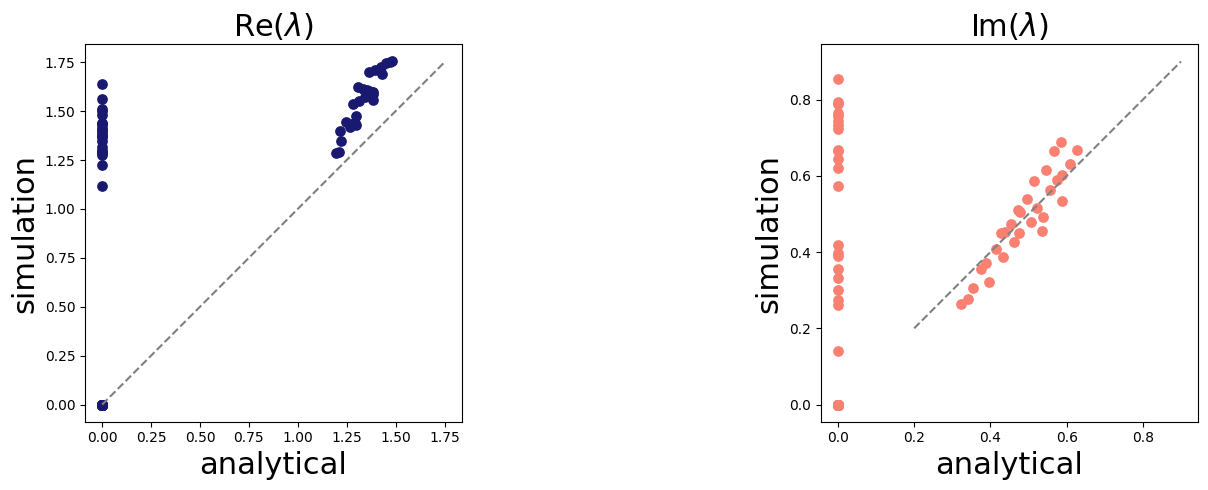

In [4]:
dat=sdf
s=45
fn = 22
fig, ax = plt.subplots(1,2,figsize=(16,5))
c1, c2 = 'midnightblue', 'salmon'
Xre = np.linspace(0,1.75,100)

ax[0].scatter(dat.t_r,dat.eig_re, s=s, c=c1)
ax[0].plot(Xre,Xre, ls='--', c='grey')
ax[0].set_ylabel(r"simulation", fontsize=fn) 
ax[0].set_xlabel(r"analytical", fontsize=fn) 
ax[0].set_title(r'$\mathrm{Re}(\lambda$)', fontsize=fn)



Xim = np.linspace(0.2,0.9,100)
ax[1].scatter( dat.t_i,dat.eig_im, s=s, c=c2)
ax[1].plot(Xim,Xim, ls='--', c='grey')
ax[1].set_ylabel(r"simulation", fontsize=fn) 
ax[1].set_xlabel(r"analytical", fontsize=fn) 
ax[1].set_title(r'$\mathrm{Im}(\lambda$)', fontsize=fn)

for i in range(2):
    ax[i].set_aspect('equal')
plt.tight_layout()
fig.savefig(figdir + '/sm_figs/analytic_rand.png', dpi=300, bbox_inches='tight')

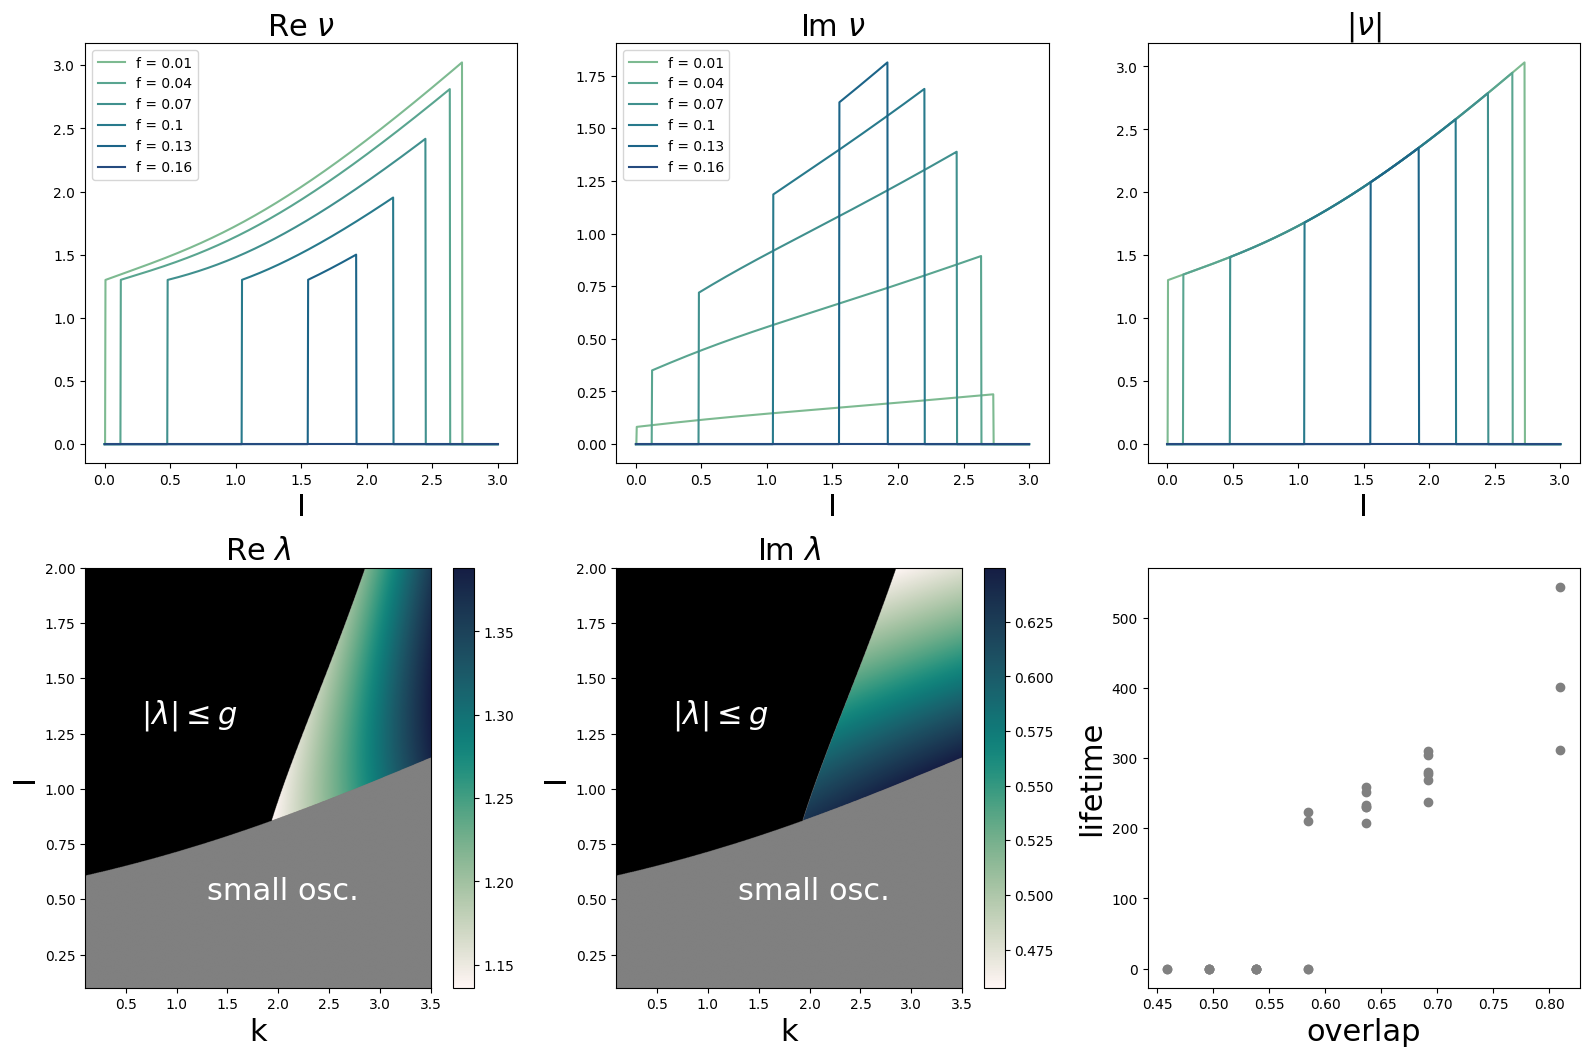

In [5]:
fig, ax = plt.subplots(2,3,figsize=(16,16/1.5))
# nu simulation parameters
nr = 1000
Is = np.linspace(.001,3,nr)
fs = np.linspace(0.01,.16,6) 
oms= fs* 2 * np.pi 
nus = np.zeros((len(Is),len(oms)),dtype=np.complex64)
lams = np.zeros((len(Is),len(oms)),dtype=np.complex64)

k,g = 3., 1.3 
cm = sns.color_palette("crest",n_colors=len(oms))
# populate nu 
for i in range(len(Is)): 
    for j in range(len(oms)): 
        lam,nu=get_the(Is[i], k, g, oms[j])
        nu = nu * (lam > 0)
        nus[i,j] = nu
        lams[i,j]=lam
# plot nu 
for j in range(len(oms)): 
    ax[0,0].plot(Is, nus[:,j].real,label=rf'f = {fs[j].round(2)}', c=cm[j])
    ax[0,1].plot(Is,nus[:,j].imag,label=rf'f = {fs[j].round(2)}', c=cm[j])
    ax[0,2].plot(Is, np.abs(nus[:,j]),label=rf'f = {fs[j].round(2)}', c=cm[j])
    # ax[3].plot(Is, np.imag(lams[:,j]), c=c_im[j])




# phase diagram 
nr = 1000
Is = np.linspace(0.1,2,nr)
ks = np.linspace(0.1,3.5,nr)
om = 2*np.pi*0.1
# g = 1.3 
g=1.3
lams = np.zeros((len(Is),len(ks)),dtype=np.complex64)
so_flags = np.zeros((len(Is),len(ks)))
for i, I in enumerate(Is): 
    for j, k in enumerate(ks): 
        lam,nu,flag=get_the(Is[i], ks[j], g, om,return_flag=True)
        lams[i,j]=lam
        so_flags[i,j]=1*flag

# make it so that wherever you're not s.o. the flag is nan 
so_flags[lams==0] += 1 

# config imshow        
extent = [ks.min(), ks.max(), Is.min(), Is.max()]
cm=cmaps.tempo
non_zer_lam = lams[lams!=0]
kwargs={'origin':'lower','extent':extent,'aspect':'auto'}
im1=ax[1,0].imshow(lams.real, vmin=non_zer_lam.real.min(), vmax=non_zer_lam.real.max(),cmap=cm, **kwargs)
im2=ax[1,1].imshow(lams.imag, vmin=non_zer_lam.imag.min(), vmax=non_zer_lam.imag.max(),cmap=cm, **kwargs)
cb=plt.colorbar(im1,ax=ax[1,0])
# cb.set_label(label=r'Re $\lambda$',fontsize=fn) 
cb=plt.colorbar(im2,ax=ax[1,1])
# cb.set_label(label=r'Im $\lambda$',fontsize=fn) 
# demarcate regions
cms=ListedColormap(['none', 'black', 'grey'])
ax[1,0].imshow(so_flags,**kwargs,cmap=cms)
ax[1,1].imshow(so_flags,**kwargs,cmap=cms)

ax[1,0].set_xlabel("k", fontsize=fn)
ax[1,1].set_xlabel("k", fontsize=fn)
ax[1,0].set_ylabel("I", fontsize=fn)
ax[1,1].set_ylabel("I", fontsize=fn)

#compute boundaries
boundary_so=Is[::-1][(so_flags[::-1]==2).argmax(0)+1]
boundary_r=Is[(so_flags==1).argmax(0)] 
boundary_r[boundary_r==Is.min()] = np.nan # mask out the region where you never see this line

# cb = 'white'
# lwn=2
# ax[1,0].plot(ks, boundary_so,c=cb,lw=lwn)
# ax[1,1].plot(ks, boundary_so,c=cb,lw=lwn)
# ax[1,0].plot(ks, boundary_r,c=cb,lw=lwn)
# ax[1,1].plot(ks, boundary_r,c=cb,lw=lwn)


# titles top row
names = ['Re ', 'Im ']
for i in range(2): 
    ax[0,i].set_title(names[i] + r'$\nu$',fontsize=fn)
    ax[1,i].set_title(names[i] + r'$\lambda$',fontsize=fn)
    ax[0,i].set_xlabel("I", fontsize=fn)
    ax[0,i].legend()

    ax[1,i].text(1.3,0.5,"small osc.",fontsize=fn,c='white')
    ax[1,i].text(0.65,1.3,r"$|\lambda|\leq g$",fontsize=fn,c='white')
ax[0,2].set_title(r"$|\nu|$",fontsize=fn)
ax[0,2].set_xlabel("I",fontsize=fn)

# lifetime vs olap
ax[1,2].scatter(dat.olap, dat.life, c='grey',alpha=1)
ax[1,2].set_ylabel("lifetime", fontsize=fn)
ax[1,2].set_xlabel("overlap", fontsize=fn)
plt.tight_layout()
fig.savefig(figdir +  '/sm_figs/nu_plot.png', dpi=300, transparent=True, bbox_inches='tight')

In [3]:
# phase diagram 
nr = 1000
I = 1. 
fn=16
gs = np.linspace(0.1, 2., nr)
ks = np.linspace(0.1,5.,nr)
om = 2*np.pi*0.1
extent=[ks.min(), ks.max(), gs.min(),gs.max()]
lams = np.zeros((len(gs),len(ks)),dtype=np.complex64)
so_flags = np.zeros((len(gs),len(ks)))

for i, g in enumerate(gs): 
    for j, k in enumerate(ks): 
        lam,nu,flag=get_the(I, k, g, om,return_flag=True)
        lams[i,j]=lam
        so_flags[i,j]=1*flag


fig,ax=plt.subplots(1,3,figsize=(18,5)) 
cmap='mako'
im1=ax[0].imshow(lams.real, aspect='auto', origin='lower',extent=extent, cmap=cmap)
im2=ax[1].imshow(lams.imag,aspect='auto', origin='lower',extent=extent, cmap=cmap)
im3=ax[2].imshow(np.abs(lams),aspect='auto', origin='lower',extent=extent, cmap=cmap)
plt.colorbar(im1,ax=ax[0]);plt.colorbar(im2,ax=ax[1]); plt.colorbar(im3,ax=ax[2])
ax[0].set_title("Re",fontsize=fn)
ax[1].set_title("Im",fontsize=fn)
ax[2].set_title("Abs", fontsize=fn) 
ax[0].set_xlabel("k",fontsize=fn)
ax[1].set_xlabel("k",fontsize=fn)
ax[1].set_ylabel("g",fontsize=fn)
ax[0].set_ylabel("g",fontsize=fn)
ax[2].set_xlabel("k",fontsize=fn)
ax[2].set_ylabel("g",fontsize=fn)
ax[0].set_box_aspect(1)
ax[1].set_box_aspect(1)
ax[2].set_box_aspect(1) 
plt.tight_layout()
fig.savefig(figdir + '/sm_figs/g_k_plane.png', dpi=300,bbox_inches='tight')

NameError: name 'get_the' is not defined

In [23]:
resdir = outdir + '/test_every_eig/test_targ_analytic/results.csv'
df = pd.read_csv(resdir) 
df['eig_out'] = df.eig_out.values.astype(np.complex128)
df['targ_emp'] = df.targ_emp.values.astype(np.complex128)
df['the'] = 4 * df.k / np.pi**2 + df.targ_emp # phi = sgn expansion
# df['the'] = df.k / 4 + df.targ_emp # phi = gamma x expansion 
df['the'] = 4 * df.k / np.pi**2 + df.targ_emp # phi = sgn expansion

df.tail()

,Unnamed: 0,I,g,f,p,k,targ,targ_emp,eig_out,the
1195,0,15,1.3,0.05,25,3.666667,(1+0.8j),0.926992+0.782854j,2.236657+0.701689j,2.413036+0.782854j
1196,0,15,1.3,0.05,25,4.000000,(1+0.8j),0.956460+0.763968j,2.425889+0.667225j,2.577599+0.763968j
1197,0,15,1.3,0.05,25,4.333333,(1+0.8j),1.026530+0.765852j,2.621629+0.702676j,2.782764+0.765852j
1198,0,15,1.3,0.05,25,4.666667,(1+0.8j),1.031957+0.777085j,2.743424+0.683057j,2.923286+0.777085j
1199,0,15,1.3,0.05,25,5.000000,(1+0.8j),0.991298+0.745454j,2.829132+0.654175j,3.017722+0.745454j


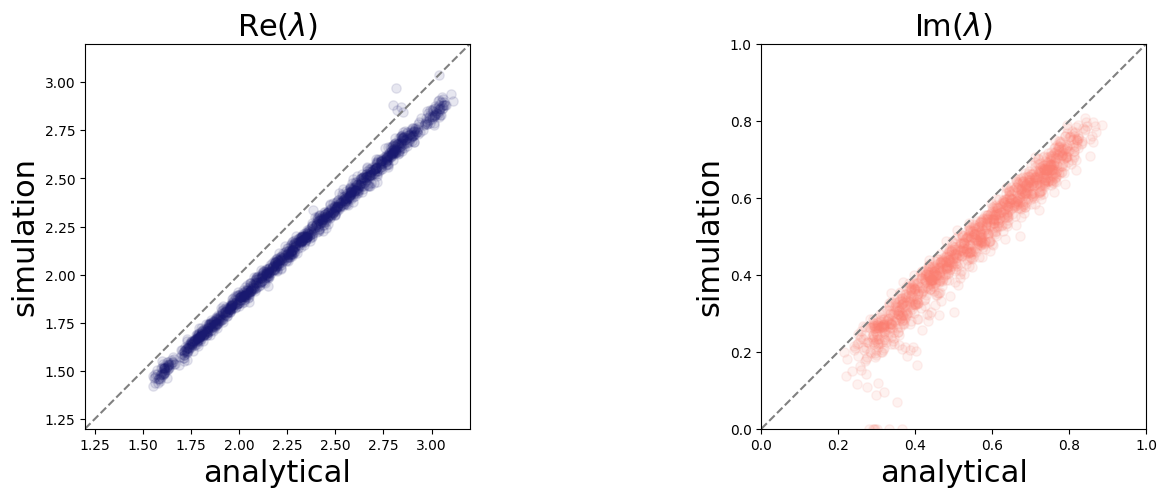

In [24]:
dat=sdf
alph=0.1
fig, ax = plt.subplots(1,2,figsize=(16,5))
xl,xu =  1.2, 3.2
Xre = np.linspace(xl,xu,100)

ax[0].scatter(df.the.values.real,df.eig_out.values.real, s=s, c=c1, alpha=alph)
ax[0].plot(Xre,Xre, ls='--', c='grey')
ax[0].set_ylabel(r"simulation", fontsize=fn) 
ax[0].set_xlabel(r"analytical", fontsize=fn) 
ax[0].set_title(r'$\mathrm{Re}(\lambda$)', fontsize=fn)
ax[0].set_xlim((xl,xu))
ax[0].set_ylim((xl,xu))

# Xim = np.linspace(0.2,1,100)
xl,xu = 0, 1.
Xim = np.linspace(xl,xu,100)

ax[1].scatter(df.the.values.imag, df.eig_out.values.imag, s=s, c=c2, alpha=alph)
ax[1].plot(Xim,Xim, ls='--', c='grey')
ax[1].set_ylabel(r"simulation", fontsize=fn) 
ax[1].set_xlabel(r"analytical", fontsize=fn) 
ax[1].set_title(r'$\mathrm{Im}(\lambda$)', fontsize=fn)
ax[1].set_xlim((xl,xu))
ax[1].set_ylim((xl,xu))

for i in range(2):
    ax[i].set_aspect('equal')
fig.savefig(figdir + '/sm_figs/analytic_targ.png', dpi=300, bbox_inches='tight')
# ax[0].set_xlim([0,1.7])